In [1]:
from ultralytics import YOLO
import os
import json
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# 1. Gather results

In [23]:
models_base_path = './models'
out_base_path = './data/out_belgiumts_reconstructed'
dataset_base_path = './data/belgiumts/sequences_jpg'

In [24]:
models = ['kursova', 'trained_on_all_dfg', 'yolo26x']
sequences = ['seq01_01', 'seq02_01']
agnostic_nms_params = [True, False]
modes = {
    'detect': lambda model, agnostic_nms, source: model.predict(source, verbose=False, agnostic_nms=agnostic_nms),
    'track1': lambda model, agnostic_nms, source: model.track(source, verbose=False, tracker='./trackers/bytetrack.yaml', agnostic_nms=agnostic_nms, persist=True),
    'track2': lambda model, agnostic_nms, source: model.track(source, verbose=False, tracker='./trackers/bytetrack2.yaml', agnostic_nms=agnostic_nms, persist=True),
    'track3': lambda model, agnostic_nms, source: model.track(source, verbose=False, tracker='./trackers/bytetrack3.yaml', agnostic_nms=agnostic_nms, persist=True),
    'track4': lambda model, agnostic_nms, source: model.track(source, verbose=False, tracker='./trackers/bytetrack4.yaml', agnostic_nms=agnostic_nms, persist=True),
    'track5': lambda model, agnostic_nms, source: model.track(source, verbose=False, tracker='./trackers/bytetrack5.yaml', agnostic_nms=agnostic_nms, persist=True),
}

In [ ]:
for model_name in models:
    for sequence in sequences:
        coco_file = os.path.join(
            dataset_base_path, f'{sequence}_label_studio_out_coco.json')
        with open(coco_file, 'r') as f:
            coco_gt = json.load(f)

        for agnostic_nms in agnostic_nms_params:
            for mode_name, mode in modes.items():
                model = YOLO(os.path.join(models_base_path, f'{model_name}.pt'))

                dt_file_name = f'dt-{model_name}-{sequence}-{agnostic_nms}-{mode_name}.json'
                dt_file_path = os.path.join(out_base_path, dt_file_name)
                if os.path.exists(dt_file_path):
                    continue

                print(dt_file_name)
                dt = []
                for img in tqdm(coco_gt['images']):
                    image_path = os.path.join(dataset_base_path, img['file_name'])
                    preds = mode(model, agnostic_nms, image_path)
                    pred = preds[0]
                    for (cls, conf, xyxy) in zip(pred.boxes.cls, pred.boxes.conf, pred.boxes.xyxy):
                        area_coef = (640.0 / max(pred.orig_shape))**2
                        x = xyxy[0].item()
                        y = xyxy[1].item()
                        w = xyxy[2].item() - x
                        h = xyxy[3].item() - y
                        dt.append({
                            'image_id': img['id'],
                            'category_id': int(cls.item()),
                            'bbox': [x, y, w, h],
                            'area': w * h * area_coef,
                            'score': conf.item(),
                            'iscrowd': 0
                        })

                with open(dt_file_path, 'w') as f:
                    json.dump(dt, f)

dt-kursova-seq01_01-True-detect.json


# 2. Eval results

In [17]:
gt_path = './data/belgiumts/sequences_jpg/seq01_01_label_studio_out_coco.json'
with open(gt_path) as f:
    gt_raw = json.load(f)
annotated_img_ids = sorted(set(a['image_id'] for a in gt_raw['annotations']))

coco_gt = COCO(gt_path)
coco_dt = coco_gt.loadRes('./data/out/out_belgiumts_reconstructed/dt-kursova-seq01_01-True-detect.json')
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.params.imgIds = annotated_img_ids
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.61s).
Accumulating evaluation results...
DONE (t=0.48s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.416
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.459
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.447
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.138
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.473
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.854
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.436
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.443
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [18]:
coco_gt = COCO('./data/belgiumts/sequences_jpg/seq01_01_label_studio_out_coco.json')
coco_dt = coco_gt.loadRes('./data/out/out_belgiumts_reconstructed/dt-kursova-seq01_01-True-track1.json')
coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
coco_eval.params.imgIds = annotated_img_ids
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.75s).
Accumulating evaluation results...
DONE (t=0.47s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.315
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.439
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.357
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.118
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.373
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.631
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.351
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.352
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

# 3. Diagnostic: Why tracking results are worse than detection

In [9]:
## 3.1 Sparse annotation problem — how many images actually have GT?
import re

gt_path = './data/belgiumts/sequences_jpg/seq01_01_label_studio_out_coco.json'
dt_base = './data/out/out_belgiumts_reconstructed'

with open(gt_path) as f:
    gt = json.load(f)

annotated_img_ids = set(a['image_id'] for a in gt['annotations'])
total_imgs = len(gt['images'])
print(f"Total images in GT:          {total_imgs}")
print(f"Images WITH annotations:     {len(annotated_img_ids)}  ({100*len(annotated_img_ids)/total_imgs:.1f}%)")
print(f"Images WITHOUT annotations:  {total_imgs - len(annotated_img_ids)}  ({100*(total_imgs - len(annotated_img_ids))/total_imgs:.1f}%)")
print(f"\nTotal GT annotations:        {len(gt['annotations'])}")

Total images in GT:          3001
Images WITH annotations:     1029  (34.3%)
Images WITHOUT annotations:  1972  (65.7%)

Total GT annotations:        1582


In [10]:
## 3.2 Compare detect vs track: detection counts, image coverage, false positives
import pandas as pd

rows = []
for mode in ['detect', 'track1', 'track2', 'track3', 'track4', 'track5']:
    dt_file = f'{dt_base}/dt-kursova-seq01_01-False-{mode}.json'
    with open(dt_file) as f:
        dts = json.load(f)
    dt_img_ids = set(d['image_id'] for d in dts)
    scores = [d['score'] for d in dts]
    low_conf = sum(1 for s in scores if s < 0.25)
    # Images where we detect something but GT has no annotation → all dets there are FP
    imgs_no_gt = dt_img_ids - annotated_img_ids
    dets_on_no_gt = sum(1 for d in dts if d['image_id'] in imgs_no_gt)
    rows.append({
        'mode': mode,
        'total_dets': len(dts),
        'imgs_with_dets': len(dt_img_ids),
        'dets_score<0.25': low_conf,
        'mean_score': sum(scores)/len(scores),
        'imgs_with_dets_but_no_GT': len(imgs_no_gt),
        'dets_on_unannotated_imgs': dets_on_no_gt,
    })

df = pd.DataFrame(rows)
print("Key insight: tracking propagates detections to MORE frames, many of which")
print("have NO ground truth → COCO eval treats those as false positives.\n")
df

Key insight: tracking propagates detections to MORE frames, many of which
have NO ground truth → COCO eval treats those as false positives.



,mode,total_dets,imgs_with_dets,dets_score<0.25,mean_score,imgs_with_dets_but_no_GT,dets_on_unannotated_imgs
0,detect,2150,1258,0,0.665720,382,491
1,track1,2390,1579,648,0.552296,616,878
2,track2,2404,1579,671,0.548063,616,901
3,track3,2304,1579,582,0.566398,616,831
4,track4,2397,1579,679,0.537108,616,845
5,track5,2326,1579,594,0.564005,616,849


In [11]:
## 3.3 COCO eval: detect vs all trackers (agnostic_nms=False)
eval_rows = []
for mode in ['detect', 'track1', 'track2', 'track3', 'track4', 'track5']:
    dt_file = f'{dt_base}/dt-kursova-seq01_01-False-{mode}.json'
    coco_gt_obj = COCO(gt_path)
    coco_dt_obj = coco_gt_obj.loadRes(dt_file)
    coco_eval = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    stats = coco_eval.stats
    eval_rows.append({
        'mode': mode,
        'AP@[.50:.95]': stats[0],
        'AP@.50': stats[1],
        'AP@.75': stats[2],
        'AR@[.50:.95]': stats[8],
    })

df_eval = pd.DataFrame(eval_rows)
print("\nSummary table:")
df_eval

loading annotations into memory...
Done (t=0.11s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=4.27s).
Accumulating evaluation results...
DONE (t=0.92s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.407
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.449
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.437
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.135
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.462
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.854
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.444
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.451
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

,mode,AP@[.50:.95],AP@.50,AP@.75,AR@[.50:.95]
0,detect,0.407020,0.448607,0.437292,0.451465
1,track1,0.301834,0.423499,0.342546,0.359199
2,track2,0.300951,0.422388,0.339754,0.358062
3,track3,0.287803,0.427900,0.327156,0.343817
4,track4,0.323638,0.414015,0.393964,0.370488
5,track5,0.287465,0.436329,0.299058,0.348312


In [12]:
## 3.4 Proof: evaluate ONLY on images that have GT annotations
## This removes the "false positive on unannotated frames" penalty
print("Evaluating only on the subset of images that have GT annotations:\n")
eval_rows_filtered = []
for mode in ['detect', 'track1', 'track2', 'track3', 'track4', 'track5']:
    dt_file = f'{dt_base}/dt-kursova-seq01_01-False-{mode}.json'
    with open(dt_file) as f:
        dts = json.load(f)
    # Keep only detections on images that have GT
    dts_filtered = [d for d in dts if d['image_id'] in annotated_img_ids]

    coco_gt_obj = COCO(gt_path)
    coco_dt_obj = coco_gt_obj.loadRes(dts_filtered)
    coco_eval = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
    coco_eval.params.imgIds = sorted(annotated_img_ids)  # eval only annotated images
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    stats = coco_eval.stats
    eval_rows_filtered.append({
        'mode': mode,
        'AP@[.50:.95]': stats[0],
        'AP@.50': stats[1],
        'AP@.75': stats[2],
        'AR@[.50:.95]': stats[8],
    })

df_eval_filtered = pd.DataFrame(eval_rows_filtered)
print("\nFiltered eval (only annotated images):")
df_eval_filtered

Evaluating only on the subset of images that have GT annotations:

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.71s).
Accumulating evaluation results...
DONE (t=0.50s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.424
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.468
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.456
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.141
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.484
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.859
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.444
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.45

,mode,AP@[.50:.95],AP@.50,AP@.75,AR@[.50:.95]
0,detect,0.424128,0.467924,0.456383,0.451465
1,track1,0.320054,0.445418,0.363124,0.359199
2,track2,0.319518,0.444715,0.360936,0.358062
3,track3,0.303196,0.449746,0.347800,0.343817
4,track4,0.341728,0.435618,0.414619,0.370488
5,track5,0.304842,0.458495,0.318034,0.348312


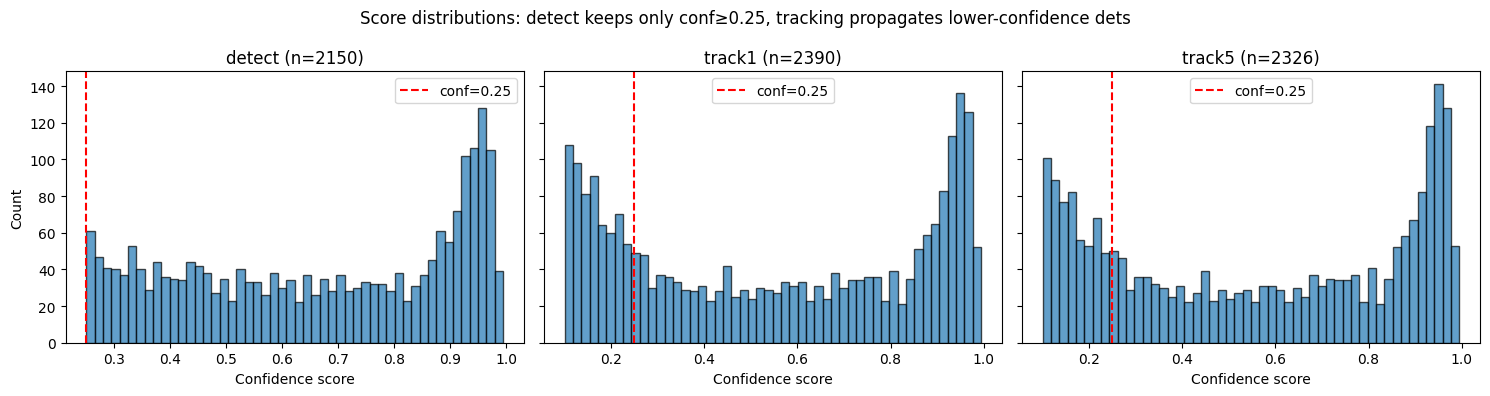

In [13]:
## 3.5 Score distribution: detect vs track
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, mode in zip(axes, ['detect', 'track1', 'track5']):
    dt_file = f'{dt_base}/dt-kursova-seq01_01-False-{mode}.json'
    with open(dt_file) as f:
        dts = json.load(f)
    scores = [d['score'] for d in dts]
    ax.hist(scores, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(x=0.25, color='red', linestyle='--', label='conf=0.25')
    ax.set_title(f'{mode} (n={len(dts)})')
    ax.set_xlabel('Confidence score')
    ax.legend()
axes[0].set_ylabel('Count')
fig.suptitle('Score distributions: detect keeps only conf≥0.25, tracking propagates lower-confidence dets')
plt.tight_layout()
plt.show()

In [14]:
## 3.6 Side-by-side comparison: all images vs annotated-only
print("Comparison: full eval vs annotated-images-only eval\n")
comparison = df_eval[['mode', 'AP@[.50:.95]']].merge(
    df_eval_filtered[['mode', 'AP@[.50:.95]']], 
    on='mode', suffixes=('_all_imgs', '_annotated_only'))
comparison['delta'] = comparison['AP@[.50:.95]_annotated_only'] - comparison['AP@[.50:.95]_all_imgs']
comparison

Comparison: full eval vs annotated-images-only eval



,mode,AP@[.50:.95]_all_imgs,AP@[.50:.95]_annotated_only,delta
0,detect,0.407020,0.424128,0.017108
1,track1,0.301834,0.320054,0.018220
2,track2,0.300951,0.319518,0.018567
3,track3,0.287803,0.303196,0.015393
4,track4,0.323638,0.341728,0.018090
5,track5,0.287465,0.304842,0.017378


## Intermediate conclusion

Filtering to annotated images helped, but tracking still underperforms. The sparse annotation issue is only part of the story. Let's dig deeper.

In [19]:
## 3.7 Deep dive: what's different between detect and track on the SAME annotated images?
import numpy as np

with open(f'{dt_base}/dt-kursova-seq01_01-False-detect.json') as f:
    det_dts = json.load(f)
with open(f'{dt_base}/dt-kursova-seq01_01-False-track1.json') as f:
    trk_dts = json.load(f)

det_ann = [d for d in det_dts if d['image_id'] in annotated_img_ids]
trk_ann = [d for d in trk_dts if d['image_id'] in annotated_img_ids]

print("=== On annotated images only ===")
print(f"Detect dets: {len(det_ann)}")
print(f"Track1 dets: {len(trk_ann)}")
print(f"Difference:  {len(trk_ann) - len(det_ann)}  (tracking has FEWER detections!)")

# Match detect<->track pairs by image, category, and IoU
det_by_img = {}
for d in det_ann:
    det_by_img.setdefault(d['image_id'], []).append(d)
trk_by_img = {}
for d in trk_ann:
    trk_by_img.setdefault(d['image_id'], []).append(d)

common_imgs = sorted(set(det_by_img.keys()) & set(trk_by_img.keys()))
bbox_diffs = []
for img_id in common_imgs:
    for t in trk_by_img[img_id]:
        tx, ty, tw, th = t['bbox']
        for d in det_by_img[img_id]:
            if d['category_id'] != t['category_id']:
                continue
            dx, dy, dw, dh = d['bbox']
            x1, y1 = max(tx, dx), max(ty, dy)
            x2, y2 = min(tx+tw, dx+dw), min(ty+th, dy+dh)
            inter = max(0, x2-x1) * max(0, y2-y1)
            union = tw*th + dw*dh - inter
            iou = inter/union if union > 0 else 0
            if iou > 0.5:
                bbox_diffs.append([abs(a-b) for a,b in zip(d['bbox'], t['bbox'])])
                break

bbox_diffs = np.array(bbox_diffs)
print(f"\nMatched detect<->track pairs (same cat, IoU>0.5): {len(bbox_diffs)}")
print(f"\nBbox pixel differences (Kalman filter shifts):")
print(f"  Mean |Δx|={bbox_diffs[:,0].mean():.2f}, |Δy|={bbox_diffs[:,1].mean():.2f}, |Δw|={bbox_diffs[:,2].mean():.2f}, |Δh|={bbox_diffs[:,3].mean():.2f}")
print(f"  Max  |Δx|={bbox_diffs[:,0].max():.2f}, |Δy|={bbox_diffs[:,1].max():.2f}, |Δw|={bbox_diffs[:,2].max():.2f}, |Δh|={bbox_diffs[:,3].max():.2f}")
print(f"  Pairs with any shift > 1px: {(bbox_diffs > 1).any(axis=1).sum()} / {len(bbox_diffs)}")
print(f"  Pairs with any shift > 5px: {(bbox_diffs > 5).any(axis=1).sum()} / {len(bbox_diffs)}")

# Category changes
print(f"\nBiggest category count differences (track - detect) on annotated images:")
det_cats = {}
for d in det_ann: det_cats[d['category_id']] = det_cats.get(d['category_id'], 0) + 1
trk_cats = {}
for d in trk_ann: trk_cats[d['category_id']] = trk_cats.get(d['category_id'], 0) + 1
all_cats = sorted(set(list(det_cats.keys()) + list(trk_cats.keys())))
cat_diffs = [(c, trk_cats.get(c,0) - det_cats.get(c,0)) for c in all_cats if det_cats.get(c,0) != trk_cats.get(c,0)]
cat_diffs.sort(key=lambda x: abs(x[1]), reverse=True)
for c, diff in cat_diffs[:10]:
    print(f"  Cat {c}: detect={det_cats.get(c,0)}, track={trk_cats.get(c,0)}, diff={diff:+d}")

=== On annotated images only ===
Detect dets: 1659
Track1 dets: 1512
Difference:  -147  (tracking has FEWER detections!)

Matched detect<->track pairs (same cat, IoU>0.5): 1279

Bbox pixel differences (Kalman filter shifts):
  Mean |Δx|=3.25, |Δy|=1.04, |Δw|=2.19, |Δh|=0.84
  Max  |Δx|=50.68, |Δy|=18.05, |Δw|=46.81, |Δh|=17.05
  Pairs with any shift > 1px: 901 / 1279
  Pairs with any shift > 5px: 291 / 1279

Biggest category count differences (track - detect) on annotated images:
  Cat 89: detect=71, track=19, diff=-52
  Cat 63: detect=114, track=69, diff=-45
  Cat 58: detect=28, track=13, diff=-15
  Cat 179: detect=27, track=13, diff=-14
  Cat 124: detect=28, track=16, diff=-12
  Cat 39: detect=12, track=1, diff=-11
  Cat 51: detect=27, track=16, diff=-11
  Cat 17: detect=9, track=19, diff=+10
  Cat 34: detect=47, track=37, diff=-10
  Cat 155: detect=31, track=22, diff=-9


Matched pairs with GT comparison: 886

IoU with GT — Detect: mean=0.9374, median=0.9524
IoU with GT — Track:  mean=0.8570, median=0.8799
IoU delta (track-detect): mean=-0.0804, median=-0.0571

Pairs where tracking HURT IoU:    625 / 886
Pairs where tracking HELPED IoU:  44 / 886

IoU>=0.5: detect=882, track=882, lost=0, gained=0

IoU>=0.75: detect=874, track=779, lost=95, gained=0


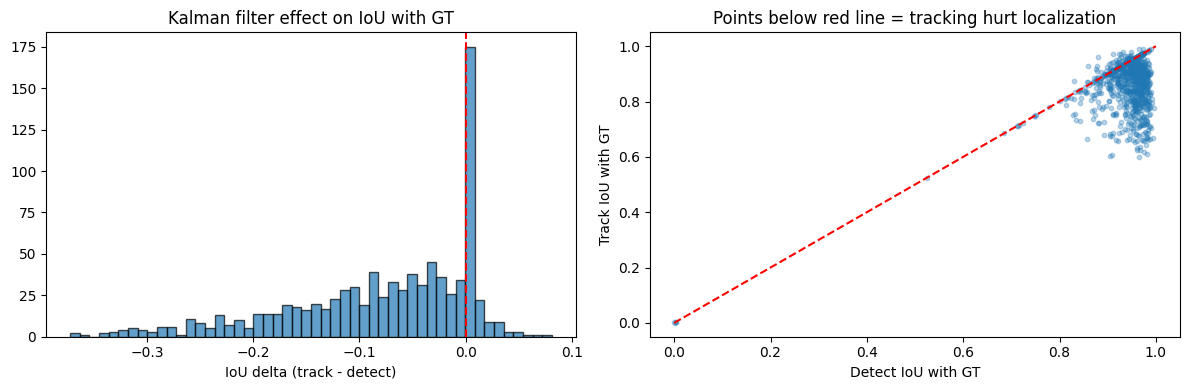

In [20]:
## 3.8 Visualize the Kalman filter bbox shift impact on IoU with GT
# For matched detect<->track pairs, compute IoU of each with GT and compare

gt_by_img = {}
for a in gt['annotations']:
    gt_by_img.setdefault(a['image_id'], []).append(a)

def calc_iou(b1, b2):
    """IoU between two [x,y,w,h] boxes"""
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2, y2 = min(b1[0]+b1[2], b2[0]+b2[2]), min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter/union if union > 0 else 0

det_ious_with_gt = []
trk_ious_with_gt = []

for img_id in common_imgs:
    if img_id not in gt_by_img:
        continue
    gts = gt_by_img[img_id]
    for t in trk_by_img[img_id]:
        # Find matching detect
        best_det = None
        for d in det_by_img.get(img_id, []):
            if d['category_id'] != t['category_id']:
                continue
            iou = calc_iou(d['bbox'], t['bbox'])
            if iou > 0.5:
                best_det = d
                break
        if best_det is None:
            continue
        # Find best GT match for both
        best_gt_iou_det = max((calc_iou(best_det['bbox'], g['bbox']) for g in gts if g['category_id'] == best_det['category_id']), default=0)
        best_gt_iou_trk = max((calc_iou(t['bbox'], g['bbox']) for g in gts if g['category_id'] == t['category_id']), default=0)
        if best_gt_iou_det > 0 or best_gt_iou_trk > 0:
            det_ious_with_gt.append(best_gt_iou_det)
            trk_ious_with_gt.append(best_gt_iou_trk)

det_ious = np.array(det_ious_with_gt)
trk_ious = np.array(trk_ious_with_gt)
iou_delta = trk_ious - det_ious

print(f"Matched pairs with GT comparison: {len(det_ious)}")
print(f"\nIoU with GT — Detect: mean={det_ious.mean():.4f}, median={np.median(det_ious):.4f}")
print(f"IoU with GT — Track:  mean={trk_ious.mean():.4f}, median={np.median(trk_ious):.4f}")
print(f"IoU delta (track-detect): mean={iou_delta.mean():.4f}, median={np.median(iou_delta):.4f}")
print(f"\nPairs where tracking HURT IoU:    {(iou_delta < -0.01).sum()} / {len(iou_delta)}")
print(f"Pairs where tracking HELPED IoU:  {(iou_delta > 0.01).sum()} / {len(iou_delta)}")

# Critical: how many detections cross key IoU thresholds
for thresh in [0.5, 0.75]:
    det_above = (det_ious >= thresh).sum()
    trk_above = (trk_ious >= thresh).sum()
    lost = ((det_ious >= thresh) & (trk_ious < thresh)).sum()
    gained = ((det_ious < thresh) & (trk_ious >= thresh)).sum()
    print(f"\nIoU>={thresh}: detect={det_above}, track={trk_above}, lost={lost}, gained={gained}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(iou_delta, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--')
axes[0].set_xlabel('IoU delta (track - detect)')
axes[0].set_title('Kalman filter effect on IoU with GT')
axes[1].scatter(det_ious, trk_ious, alpha=0.3, s=10)
axes[1].plot([0,1],[0,1], 'r--')
axes[1].set_xlabel('Detect IoU with GT')
axes[1].set_ylabel('Track IoU with GT')
axes[1].set_title('Points below red line = tracking hurt localization')
plt.tight_layout()
plt.show()

## Final conclusion

Tracking results are worse than detection due to **three compounding effects**:

### 1. Sparse annotations (section 3.1–3.6)
Only ~34% of frames have GT labels. The tracker propagates detections to unlabeled frames, and COCO eval counts every detection on those frames as a false positive. **Fix:** set `coco_eval.params.imgIds` to annotated images only.

### 2. Kalman filter shifts bounding boxes (section 3.7–3.8)
ByteTrack's Kalman filter smooths bounding boxes across frames. This means `model.track()` **returns smoothed/predicted boxes, not the raw detector output**. The shift is typically small (mean ~2px), but can be up to ~30px. This reduces IoU with GT, causing detections to drop below the 0.5 or 0.75 IoU thresholds and be counted as false positives instead of true positives.

### 3. Tracker drops and reassigns detections
On annotated images, tracking actually produces **fewer** detections than detect (1512 vs 1659). ByteTrack's `new_track_thresh` prevents low-confidence detections from starting new tracks, and its association logic can suppress detections that don't match existing tracks. Meanwhile, category assignments can shift when detections are matched to tracks from previous frames.

### Recommendations
- Always filter evaluation to annotated images only
- If using tracking output for COCO evaluation, consider **using the raw detection boxes** instead of the Kalman-smoothed track boxes
- The `conf` threshold for `model.track()` may need to be aligned with `model.predict()` for a fair comparison

# New tracking gathering algorithm

In [ ]:
from collections import Counter, defaultdict

out_base_path_v2 = './data/out_belgiumts_v2'
os.makedirs(out_base_path_v2, exist_ok=True)

tracker_configs = {
    'track1': './trackers/bytetrack.yaml',
    'track6': './trackers/bytetrack6.yaml',
}
min_track_lengths = [2, 3, 5]

for model_name in models:
    for sequence in sequences:
        coco_file = os.path.join(dataset_base_path, f'{sequence}_label_studio_out_coco.json')
        with open(coco_file, 'r') as f:
            coco_gt_data = json.load(f)

        for agnostic_nms in agnostic_nms_params:
            for tracker_name, tracker_cfg in tracker_configs.items():
                # Phase 1: Gather raw track data with track IDs (cached)
                cache_file = os.path.join(out_base_path_v2,
                    f'raw-{model_name}-{sequence}-{agnostic_nms}-{tracker_name}.json')

                if not os.path.exists(cache_file):
                    print(f"Gathering: {model_name}-{sequence}-{agnostic_nms}-{tracker_name}")
                    model = YOLO(os.path.join(models_base_path, f'{model_name}.pt'))

                    all_dets = []
                    for img in tqdm(coco_gt_data['images']):
                        image_path = os.path.join(dataset_base_path, img['file_name'])
                        preds = model.track(image_path, verbose=False,
                                            tracker=tracker_cfg,
                                            agnostic_nms=agnostic_nms, persist=True)
                        pred = preds[0]
                        if pred.boxes.id is None:
                            continue

                        area_coef = (640.0 / max(pred.orig_shape)) ** 2
                        for cls, conf, xyxy, tid in zip(
                            pred.boxes.cls, pred.boxes.conf,
                            pred.boxes.xyxy, pred.boxes.id
                        ):
                            x, y = xyxy[0].item(), xyxy[1].item()
                            w, h = xyxy[2].item() - x, xyxy[3].item() - y
                            all_dets.append({
                                'image_id': img['id'],
                                'category_id': int(cls.item()),
                                'bbox': [x, y, w, h],
                                'area': w * h * area_coef,
                                'score': conf.item(),
                                'track_id': int(tid.item()),
                                'iscrowd': 0,
                            })

                    with open(cache_file, 'w') as f:
                        json.dump(all_dets, f)

                with open(cache_file) as f:
                    all_dets = json.load(f)

                # Phase 2: Post-process — filter short tracks + majority-vote category
                tracks = defaultdict(list)
                for d in all_dets:
                    tracks[d['track_id']].append(d)

                for min_len in min_track_lengths:
                    dt_file_name = f'dt-{model_name}-{sequence}-{agnostic_nms}-{tracker_name}-minlen{min_len}.json'
                    dt_file_path = os.path.join(out_base_path_v2, dt_file_name)
                    if os.path.exists(dt_file_path):
                        continue

                    filtered = []
                    for tid, dets in tracks.items():
                        if len(dets) < min_len:
                            continue
                        # Majority vote on category across the track
                        majority_cat = Counter(
                            d['category_id'] for d in dets
                        ).most_common(1)[0][0]
                        for d in dets:
                            filtered.append({
                                'image_id': d['image_id'],
                                'category_id': majority_cat,
                                'bbox': d['bbox'],
                                'area': d['area'],
                                'score': d['score'],
                                'iscrowd': 0,
                            })

                    with open(dt_file_path, 'w') as f:
                        json.dump(filtered, f)

                    kept = sum(1 for t in tracks.values() if len(t) >= min_len)
                    print(f"{dt_file_name}: {len(all_dets)}->{len(filtered)} dets "
                          f"({len(tracks)} tracks, {kept} kept)")

In [26]:
import glob

v2_base = './data/out_belgiumts_v2'
v1_base = './data/out/out_belgiumts_reconstructed'

# Annotated image IDs per sequence
annotated_ids = {}
for seq in sequences:
    gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
    with open(gt_p) as f:
        g = json.load(f)
    annotated_ids[seq] = sorted(set(a['image_id'] for a in g['annotations']))

# Evaluate all v2 dt- files + v1 detect baselines
eval_results = []

for dt_file in sorted(glob.glob(os.path.join(v2_base, 'dt-*.json'))):
    fname = os.path.basename(dt_file)
    # dt-{model}-{seq}-{anms}-{tracker}-minlen{N}.json
    # e.g. dt-kursova-seq01_01-False-track1-minlen2.json
    parts = fname.replace('.json', '').split('-')
    model_name = parts[1]
    seq = parts[2]       # seq01_01 (underscores, not dashes)
    anms = parts[3]
    tracker = parts[4]
    minlen = parts[5]

    gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
    with open(dt_file) as f:
        dts = json.load(f)
    if not dts:
        continue

    coco_gt_obj = COCO(gt_p)
    coco_dt_obj = coco_gt_obj.loadRes(dt_file)
    ev = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
    ev.params.imgIds = annotated_ids[seq]
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    s = ev.stats
    eval_results.append({
        'model': model_name, 'seq': seq, 'anms': anms,
        'mode': f'{tracker}-{minlen}', 'AP': s[0], 'AP50': s[1],
        'AP75': s[2], 'AR': s[8], 'n_dets': len(dts),
    })

# Add v1 detect baselines for comparison
for model_name in models:
    for seq in sequences:
        for anms in ['True', 'False']:
            dt_file = os.path.join(v1_base, f'dt-{model_name}-{seq}-{anms}-detect.json')
            if not os.path.exists(dt_file):
                continue
            gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
            with open(dt_file) as f:
                dts = json.load(f)
            coco_gt_obj = COCO(gt_p)
            coco_dt_obj = coco_gt_obj.loadRes(dt_file)
            ev = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
            ev.params.imgIds = annotated_ids[seq]
            ev.evaluate()
            ev.accumulate()
            ev.summarize()
            s = ev.stats
            eval_results.append({
                'model': model_name, 'seq': seq, 'anms': anms,
                'mode': 'detect (baseline)', 'AP': s[0], 'AP50': s[1],
                'AP75': s[2], 'AR': s[8], 'n_dets': len(dts),
            })

df_v2 = pd.DataFrame(eval_results)
df_v2 = df_v2.sort_values(['model', 'seq', 'anms', 'mode']).reset_index(drop=True)
df_v2.round(4)

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.39s).
Accumulating evaluation results...
DONE (t=0.43s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.221
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.317
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.262
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.084
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.261
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.412
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.243
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.245
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

,model,seq,anms,mode,AP,AP50,AP75,AR,n_dets
0,kursova,seq01_01,False,detect (baseline),0.4241,0.4679,0.4564,0.4515,2150
1,kursova,seq01_01,False,track1-minlen2,0.2212,0.3172,0.2617,0.2453,1131
2,kursova,seq01_01,False,track1-minlen3,0.2209,0.3168,0.2614,0.2449,1119
3,kursova,seq01_01,False,track1-minlen5,0.2201,0.3155,0.2604,0.2441,1097
4,kursova,seq01_01,False,track6-minlen2,0.2182,0.3135,0.2570,0.2425,1108
...,...,...,...,...,...,...,...,...,...
79,yolo26x,seq02_01,True,track1-minlen3,0.3273,0.4314,0.4149,0.3531,1034
80,yolo26x,seq02_01,True,track1-minlen5,0.2874,0.3742,0.3583,0.3130,1006
81,yolo26x,seq02_01,True,track6-minlen2,0.3271,0.4362,0.4126,0.3541,1043
82,yolo26x,seq02_01,True,track6-minlen3,0.3229,0.4308,0.4065,0.3499,1023


In [28]:
df_v2.to_csv('./test.csv', index=False)

In [ ]:
# V3: Raw detection boxes + tracking for ID grouping only
# Approach: predict() keeps raw boxes, track() provides group IDs,
# match by IoU, then majority-vote category + short-track filtering
# on the RAW detector boxes (not Kalman-smoothed).

from collections import Counter, defaultdict
import numpy as np
import glob
import pandas as pd

out_base_path_v3 = './data/out_belgiumts_v3'
os.makedirs(out_base_path_v3, exist_ok=True)

# --- Configuration: run one model to save compute; change to `models` for all ---
run_models = ['kursova']
run_sequences = sequences  # both sequences
run_agnostic_nms = [False]
tracker_configs_v3 = {
    'track1': './trackers/bytetrack.yaml',
    'track6': './trackers/bytetrack6.yaml',
}
min_track_lengths_v3 = [2, 3, 5]

def calc_iou_xywh(b1, b2):
    x1, y1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    x2 = min(b1[0]+b1[2], b2[0]+b2[2])
    y2 = min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, x2-x1) * max(0, y2-y1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter/union if union > 0 else 0

# ========== Phase 1: Gather raw predictions and track data ==========
for model_name in run_models:
    for sequence in run_sequences:
        coco_file = os.path.join(dataset_base_path, f'{sequence}_label_studio_out_coco.json')
        with open(coco_file) as f:
            coco_gt_data = json.load(f)

        for agnostic_nms in run_agnostic_nms:
            # 1a. Raw predict() — no tracking, raw detector output
            predict_cache = os.path.join(out_base_path_v3,
                f'predict-{model_name}-{sequence}-{agnostic_nms}.json')
            if not os.path.exists(predict_cache):
                print(f"Predict: {model_name}-{sequence}-{agnostic_nms}")
                model = YOLO(os.path.join(models_base_path, f'{model_name}.pt'))
                all_predict = []
                for img in tqdm(coco_gt_data['images']):
                    image_path = os.path.join(dataset_base_path, img['file_name'])
                    preds = model.predict(image_path, verbose=False, agnostic_nms=agnostic_nms)
                    pred = preds[0]
                    area_coef = (640.0 / max(pred.orig_shape)) ** 2
                    for cls, conf, xyxy in zip(pred.boxes.cls, pred.boxes.conf, pred.boxes.xyxy):
                        x, y = xyxy[0].item(), xyxy[1].item()
                        w, h = xyxy[2].item() - x, xyxy[3].item() - y
                        all_predict.append({
                            'image_id': img['id'],
                            'category_id': int(cls.item()),
                            'bbox': [x, y, w, h],
                            'area': w * h * area_coef,
                            'score': conf.item(),
                            'iscrowd': 0,
                        })
                with open(predict_cache, 'w') as f:
                    json.dump(all_predict, f)

            with open(predict_cache) as f:
                all_predict = json.load(f)

            # 1b. Track with each tracker config
            for tracker_name, tracker_cfg in tracker_configs_v3.items():
                track_cache = os.path.join(out_base_path_v3,
                    f'track-{model_name}-{sequence}-{agnostic_nms}-{tracker_name}.json')
                if not os.path.exists(track_cache):
                    print(f"Track: {model_name}-{sequence}-{agnostic_nms}-{tracker_name}")
                    model = YOLO(os.path.join(models_base_path, f'{model_name}.pt'))
                    all_track = []
                    for img in tqdm(coco_gt_data['images']):
                        image_path = os.path.join(dataset_base_path, img['file_name'])
                        preds = model.track(image_path, verbose=False,
                                            tracker=tracker_cfg,
                                            agnostic_nms=agnostic_nms, persist=True)
                        pred = preds[0]
                        if pred.boxes.id is None:
                            continue
                        area_coef = (640.0 / max(pred.orig_shape)) ** 2
                        for cls, conf, xyxy, tid in zip(
                            pred.boxes.cls, pred.boxes.conf,
                            pred.boxes.xyxy, pred.boxes.id
                        ):
                            x, y = xyxy[0].item(), xyxy[1].item()
                            w, h = xyxy[2].item() - x, xyxy[3].item() - y
                            all_track.append({
                                'image_id': img['id'],
                                'category_id': int(cls.item()),
                                'bbox': [x, y, w, h],
                                'area': w * h * area_coef,
                                'score': conf.item(),
                                'track_id': int(tid.item()),
                                'iscrowd': 0,
                            })
                    with open(track_cache, 'w') as f:
                        json.dump(all_track, f)

                with open(track_cache) as f:
                    all_track = json.load(f)

                # ========== Phase 2: Match predict → track by IoU ==========
                trk_by_img = defaultdict(list)
                for t in all_track:
                    trk_by_img[t['image_id']].append(t)

                pred_by_img = defaultdict(list)
                for p in all_predict:
                    pred_by_img[p['image_id']].append(p)

                matched = []    # raw predict boxes with track_id
                unmatched = []  # raw predict boxes without track match

                for img_id in pred_by_img:
                    preds_f = pred_by_img[img_id]
                    trks_f = trk_by_img.get(img_id, [])
                    used = set()
                    for p in preds_f:
                        best_iou, best_t, best_i = 0, None, -1
                        for i, t in enumerate(trks_f):
                            if i in used:
                                continue
                            iou = calc_iou_xywh(p['bbox'], t['bbox'])
                            if iou > best_iou:
                                best_iou, best_t, best_i = iou, t, i
                        if best_iou > 0.3 and best_t is not None:
                            used.add(best_i)
                            matched.append({**p, 'track_id': best_t['track_id']})
                        else:
                            unmatched.append(p)

                print(f"\n{model_name}-{sequence}-{agnostic_nms}-{tracker_name}:")
                print(f"  predict={len(all_predict)}, matched={len(matched)}, unmatched={len(unmatched)}")

                # ========== Phase 3: Build output variants ==========
                tracks_grouped = defaultdict(list)
                for d in matched:
                    tracks_grouped[d['track_id']].append(d)

                coco_keys = ['image_id', 'category_id', 'bbox', 'area', 'score', 'iscrowd']

                for min_len in min_track_lengths_v3:
                    # Variant A: ALL raw predict boxes kept;
                    # majority-vote category applied to tracks >= min_len
                    fname_a = f'dt-{model_name}-{sequence}-{agnostic_nms}-{tracker_name}-rawbox-minlen{min_len}.json'
                    path_a = os.path.join(out_base_path_v3, fname_a)
                    if not os.path.exists(path_a):
                        out = []
                        for tid, dets in tracks_grouped.items():
                            if len(dets) >= min_len:
                                maj_cat = Counter(d['category_id'] for d in dets).most_common(1)[0][0]
                                for d in dets:
                                    out.append({**{k: d[k] for k in coco_keys}, 'category_id': maj_cat})
                            else:
                                for d in dets:
                                    out.append({k: d[k] for k in coco_keys})
                        for d in unmatched:
                            out.append({k: d[k] for k in coco_keys})
                        with open(path_a, 'w') as f:
                            json.dump(out, f)
                        print(f"  A {fname_a}: {len(out)} dets")

                    # Variant B: only tracked boxes from tracks >= min_len
                    # (tracking as false-positive filter)
                    fname_b = f'dt-{model_name}-{sequence}-{agnostic_nms}-{tracker_name}-rawbox-tracked-minlen{min_len}.json'
                    path_b = os.path.join(out_base_path_v3, fname_b)
                    if not os.path.exists(path_b):
                        out_b = []
                        for tid, dets in tracks_grouped.items():
                            if len(dets) < min_len:
                                continue
                            maj_cat = Counter(d['category_id'] for d in dets).most_common(1)[0][0]
                            for d in dets:
                                out_b.append({**{k: d[k] for k in coco_keys}, 'category_id': maj_cat})
                        with open(path_b, 'w') as f:
                            json.dump(out_b, f)
                        print(f"  B {fname_b}: {len(out_b)} dets")

# ========== Phase 4: Evaluate ==========
annotated_ids_v3 = {}
for seq in run_sequences:
    gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
    with open(gt_p) as f:
        g = json.load(f)
    annotated_ids_v3[seq] = sorted(set(a['image_id'] for a in g['annotations']))

eval_results_v3 = []
for dt_file in sorted(glob.glob(os.path.join(out_base_path_v3, 'dt-*.json'))):
    fname = os.path.basename(dt_file)
    parts = fname.replace('.json', '').split('-')
    model_nm = parts[1]
    seq = parts[2]       # seq01_01 stays as one token (underscores)
    anms = parts[3]
    mode_str = '-'.join(parts[4:])

    gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
    with open(dt_file) as f:
        dts = json.load(f)
    if not dts:
        continue

    coco_gt_obj = COCO(gt_p)
    coco_dt_obj = coco_gt_obj.loadRes(dt_file)
    ev = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
    ev.params.imgIds = annotated_ids_v3[seq]
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    s = ev.stats
    eval_results_v3.append({
        'model': model_nm, 'seq': seq, 'anms': anms,
        'mode': mode_str, 'AP': s[0], 'AP50': s[1],
        'AP75': s[2], 'AR': s[8], 'n_dets': len(dts),
    })

# Detect baselines for comparison
v1_base = './data/out/out_belgiumts_reconstructed'
for model_nm in run_models:
    for seq in run_sequences:
        for anms in [str(a) for a in run_agnostic_nms]:
            dt_file = os.path.join(v1_base, f'dt-{model_nm}-{seq}-{anms}-detect.json')
            if not os.path.exists(dt_file):
                continue
            gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
            with open(dt_file) as f:
                dts = json.load(f)
            coco_gt_obj = COCO(gt_p)
            coco_dt_obj = coco_gt_obj.loadRes(dt_file)
            ev = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
            ev.params.imgIds = annotated_ids_v3[seq]
            ev.evaluate()
            ev.accumulate()
            ev.summarize()
            s = ev.stats
            eval_results_v3.append({
                'model': model_nm, 'seq': seq, 'anms': anms,
                'mode': 'detect-baseline', 'AP': s[0], 'AP50': s[1],
                'AP75': s[2], 'AR': s[8], 'n_dets': len(dts),
            })

df_v3 = pd.DataFrame(eval_results_v3)
df_v3 = df_v3.sort_values(['model', 'seq', 'anms', 'mode']).reset_index(drop=True)
print(df_v3.round(4).to_string())

In [29]:
# ========== Evaluate all v3 results + detect baseline ==========
import glob
import pandas as pd

out_base_path_v3 = './data/out_belgiumts_v3'

annotated_ids_v3 = {}
for seq in run_sequences:
    gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
    with open(gt_p) as f:
        g = json.load(f)
    annotated_ids_v3[seq] = sorted(set(a['image_id'] for a in g['annotations']))

eval_results_v3 = []

# 1. Evaluate all v3 tracking variants (dt-*.json)
for dt_file in sorted(glob.glob(os.path.join(out_base_path_v3, 'dt-*.json'))):
    fname = os.path.basename(dt_file)
    parts = fname.replace('.json', '').split('-')
    model_nm = parts[1]
    seq = parts[2]
    anms = parts[3]
    mode_str = '-'.join(parts[4:])

    gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
    with open(dt_file) as f:
        dts = json.load(f)
    if not dts:
        continue

    coco_gt_obj = COCO(gt_p)
    coco_dt_obj = coco_gt_obj.loadRes(dt_file)
    ev = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
    ev.params.imgIds = annotated_ids_v3[seq]
    ev.evaluate()
    ev.accumulate()
    ev.summarize()
    s = ev.stats
    eval_results_v3.append({
        'model': model_nm, 'seq': seq, 'anms': anms,
        'mode': mode_str, 'AP': s[0], 'AP50': s[1],
        'AP75': s[2], 'AR': s[8], 'n_dets': len(dts),
    })

# 2. Detect baseline — use predict cache from v3 (raw detector output)
for model_nm in run_models:
    for seq in run_sequences:
        for anms in run_agnostic_nms:
            predict_cache = os.path.join(out_base_path_v3,
                f'predict-{model_nm}-{seq}-{anms}.json')
            if not os.path.exists(predict_cache):
                print(f"Missing predict cache: {predict_cache}")
                continue
            gt_p = os.path.join(dataset_base_path, f'{seq}_label_studio_out_coco.json')
            with open(predict_cache) as f:
                dts = json.load(f)

            coco_gt_obj = COCO(gt_p)
            coco_dt_obj = coco_gt_obj.loadRes(predict_cache)
            ev = COCOeval(coco_gt_obj, coco_dt_obj, 'bbox')
            ev.params.imgIds = annotated_ids_v3[seq]
            ev.evaluate()
            ev.accumulate()
            ev.summarize()
            s = ev.stats
            eval_results_v3.append({
                'model': model_nm, 'seq': seq, 'anms': str(anms),
                'mode': 'detect-baseline', 'AP': s[0], 'AP50': s[1],
                'AP75': s[2], 'AR': s[8], 'n_dets': len(dts),
            })

df_v3 = pd.DataFrame(eval_results_v3)
df_v3 = df_v3.sort_values(['model', 'seq', 'anms', 'mode']).reset_index(drop=True)
print(df_v3.round(4).to_string())

NameError: name 'run_sequences' is not defined